In [66]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from datetime import date, timedelta
import seaborn as sns
sns.set()
plt.style.use('fivethirtyeight')

#calculate date range
today = date.today()
end_date = today.strftime("%Y-%m-%d")
d2= date.today() - timedelta(days=5000)
start_date = d2.strftime("%Y-%m-%d")
print('today : ',today)
print('start_date : ',start_date)
print('end_date : ',end_date)

#data load
df = yf.download('AAPL', start=start_date, end=end_date, progress=False)
df['Date'] = df.index
df = df[["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]]
df.reset_index(drop=True, inplace=True)

# Prepare the data
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

x = X.to_numpy()
y = y.to_numpy()
y = y.reshape(-1, 1)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

# Create the DecisionTreeRegressor model
model = DecisionTreeRegressor()
# Set feature names explicitly (assuming you have three features: 'Open', 'High', 'Low')
model.feature_names_in_ = ['Open', 'High', 'Low', 'Volume']

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model performance
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print('Mean squared error:', mse)


today :  2023-09-15
start_date :  2010-01-06
end_date :  2023-09-15
Mean squared error: 0.9861747082484131


In [67]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
3441,2023-09-08,178.350006,180.240005,177.789993,178.179993,178.179993,65551300
3442,2023-09-11,180.070007,180.300003,177.339996,179.360001,179.360001,58953100
3443,2023-09-12,179.490005,180.130005,174.820007,176.300003,176.300003,90370200
3444,2023-09-13,176.509995,177.300003,173.979996,174.210007,174.210007,84267900
3445,2023-09-14,174.000000,176.100006,173.580002,175.740005,175.740005,60895800


In [68]:
# Make a prediction for the next day's closing price
open_price = df['Open'].iloc[-1]
high_price = df['High'].iloc[-1]
low_price = df['Low'].iloc[-1]
volume = df['Volume'].iloc[-1]
X_new = np.array([[open_price, high_price, low_price, volume]])
print(X_new)
y_pred = model.predict(X_new)

# Print the predicted closing price
print('Predicted closing price:', y_pred[0])


[[1.74000000e+02 1.76100006e+02 1.73580002e+02 6.08958000e+07]]
Predicted closing price: 175.74000549316406


In [69]:
# Predict the stock price for the next 5 days
last_five_days = df.tail(5)
selected_column = last_five_days[['Open', 'High', 'Low', 'Volume']]
last_five_days = selected_column.values
print(last_five_days)
X_new = last_five_days
y_pred = model.predict(X_new)

# Print the predicted stock prices for the next 5 days
print('Predicted stock prices for the next 5 days:', y_pred)# Calculate the current date
current_date = pd.Timestamp(today)
print('current_date : ',current_date)

[[1.78350006e+02 1.80240005e+02 1.77789993e+02 6.55513000e+07]
 [1.80070007e+02 1.80300003e+02 1.77339996e+02 5.89531000e+07]
 [1.79490005e+02 1.80130005e+02 1.74820007e+02 9.03702000e+07]
 [1.76509995e+02 1.77300003e+02 1.73979996e+02 8.42679000e+07]
 [1.74000000e+02 1.76100006e+02 1.73580002e+02 6.08958000e+07]]
Predicted stock prices for the next 5 days: [178.17999268 179.36000061 176.30000305 174.21000671 175.74000549]
current_date :  2023-09-15 00:00:00


In [70]:
# Calculate the current date
current_date = pd.Timestamp(today)
print('current_date : ',current_date)

# Filter data for the last 10 days from the current date
last_10_days_data = df[(df['Date'] > (current_date - pd.DateOffset(days=10))) & (df['Date'] <= current_date)]
last_10_days_data.head()

current_date :  2023-09-15 00:00:00


,Date,Open,High,Low,Close,Adj Close,Volume
3439,2023-09-06,188.399994,188.850006,181.470001,182.910004,182.910004,81755800
3440,2023-09-07,175.179993,178.210007,173.539993,177.559998,177.559998,112488800
3441,2023-09-08,178.350006,180.240005,177.789993,178.179993,178.179993,65551300
3442,2023-09-11,180.070007,180.300003,177.339996,179.360001,179.360001,58953100
3443,2023-09-12,179.490005,180.130005,174.820007,176.300003,176.300003,90370200


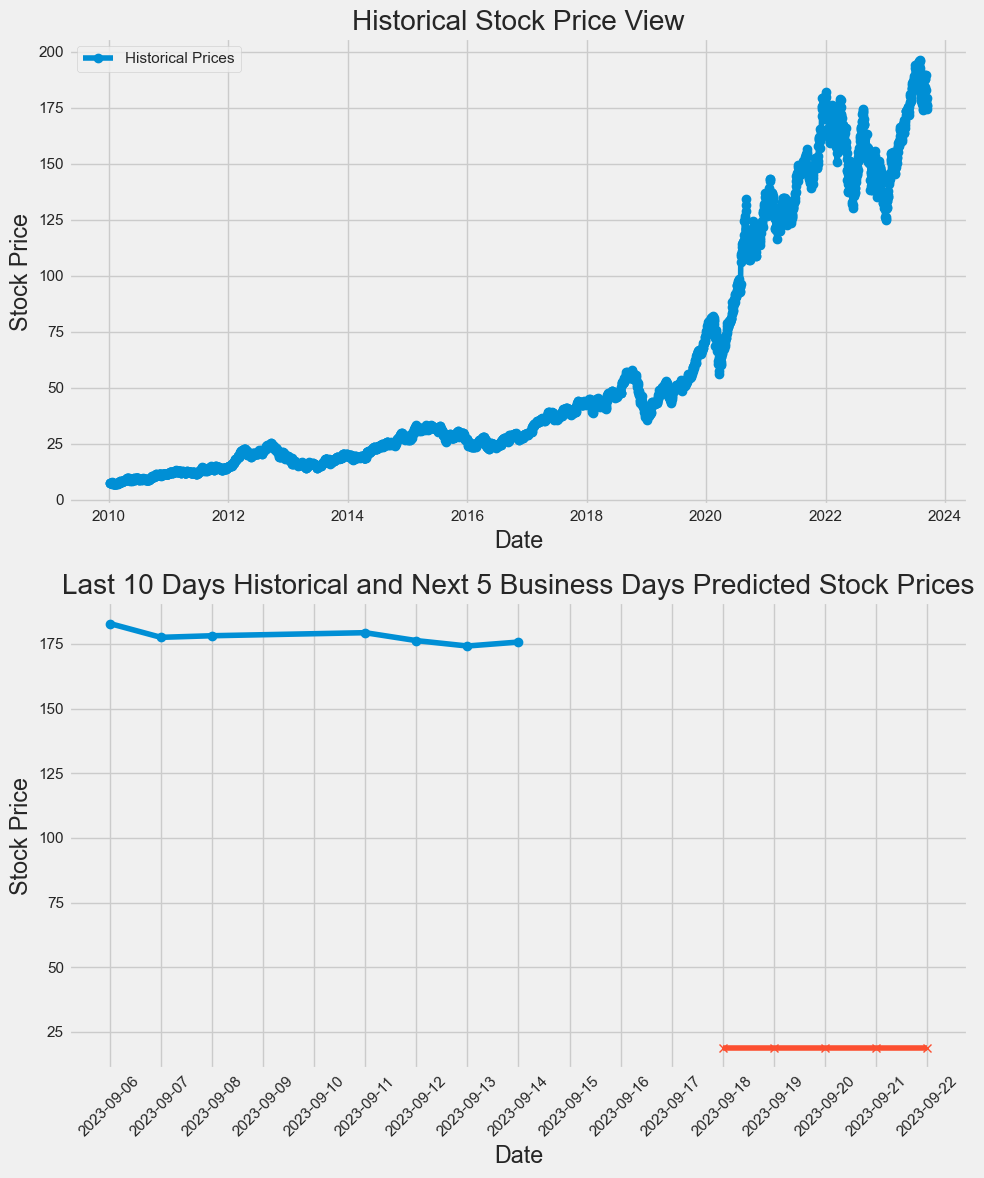

In [71]:
# Create subplots with two charts
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 12))

# Plot all historical data in the first graph
axes[0].plot(df['Date'], df['Close'], label='Historical Prices', marker='o')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Stock Price')
axes[0].set_title('Historical Stock Price View')
axes[0].legend()

# Plot the last 10 days of historical prices and the next 5 business days of predicted prices in the second graph
axes[1].plot(last_10_days_data['Date'], last_10_days_data['Close'], label='Last 10 Days Historical Prices', marker='o')
axes[1].plot(next_5_business_days, predicted_prices, label='Predicted Prices', marker='x')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Stock Price')
axes[1].set_title('Last 10 Days Historical and Next 5 Business Days Predicted Stock Prices')
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=1))  # Set daily date locator
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))  # Format date labels

# Rotate the labels by 45 degrees
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()